<a href="https://colab.research.google.com/github/rafioncode/Protein-Secondary-Structure-Prediction/blob/main/PSSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

!cp "/content/drive/MyDrive/Colab Notebooks/ML Project/raw/cb513/cb513+profile_split1_updated.npy" .
!cp "/content/drive/MyDrive/Colab Notebooks/ML Project/raw/cullpdb/cullpdb+profile_5926_filtered_updated.npy" .

cb513_data = np.load('cb513+profile_split1_updated.npy')
cullpdb_data = np.load('cullpdb+profile_5926_filtered_updated.npy')
print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
print(cb513_data.shape)
print(cullpdb_data.shape)
print(cb513_data.dtype, cullpdb_data.dtype)

(514, 700, 57)
(5365, 700, 57)
float64 float64


In [ ]:
import os

base_drive_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'

os.makedirs(base_drive_path, exist_ok=True)
print(f"Base directory created/verified: {base_drive_path}")

Base directory created/verified: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project


# Q8 -> Q3 Conversion

In [ ]:
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


def convert_q8_to_q3(q8_labels):
    q8_to_q3_map = {
        'H': 'H',  # α-helix
        'G': 'H',  # 3_10 helix
        'I': 'H',  # π-helix
        'E': 'E',  # β-strand
        'B': 'E',  # β-bridge
        'T': 'C',  # β-turn
        'S': 'C',  # Bend
        'C': 'C',  # Loop/Irregular
        ' ': 'C',  # space
        '-': 'C',  # dash
        'L': 'C'   # Loop (alternative notation)
    }

    q3_labels = ''.join([q8_to_q3_map.get(label, 'C') for label in q8_labels])
    return q3_labels


def parse_cullpdb_npy(data, prefix=''):
    # data = np.load(npy_file)
    data = data.reshape(-1, 700, 57)

    proteins = []

    aa_order = 'ACDEFGHIKLMNPQRSTVWYX'

    q8_order = 'LBEGIHST'

    for protein_idx, protein in enumerate(data):
        aa_features = protein[:, 0:22]
        aa_indices = np.argmax(aa_features, axis=1)
        sequence = ''.join([aa_order[i] if i < 21 else '' for i in aa_indices])

        q8_features = protein[:, 22:31]
        q8_indices = np.argmax(q8_features, axis=1)
        q8_labels = ''.join([q8_order[i] if i < 8 else '' for i in q8_indices])

        valid_length = len(sequence.rstrip())
        sequence = sequence[:valid_length]
        q8_labels = q8_labels[:valid_length]

        if len(sequence) == 0:
            continue

        if len(sequence) != len(q8_labels):
            raise ValueError(f"Protein {protein_idx}: Length mismatch "
                           f"(seq={len(sequence)}, labels={len(q8_labels)})")

        q3_labels = convert_q8_to_q3(q8_labels)

        proteins.append({
            'protein_id': f'{prefix}{protein_idx}',
            'sequence': sequence,
            'q8_labels': q8_labels,
            'q3_labels': q3_labels,
            'length': len(sequence)
        })

    return proteins


def validate_sequence_labels(sequence, labels):
    valid_aa = set('ACDEFGHIKLMNPQRSTVWYX')

    if len(sequence) != len(labels):
        raise ValueError(f"Length mismatch: sequence={len(sequence)}, "
                        f"labels={len(labels)}")

    invalid_aa = set(sequence) - valid_aa
    if invalid_aa:
        raise ValueError(f"Invalid amino acids: {invalid_aa}")

    if set(labels) - set('HEC'):
        raise ValueError(f"Invalid Q3 labels found")

    return True


if __name__ == '__main__':
    proteins = parse_cullpdb_npy(cullpdb_data)

    print(f"Parsed {len(proteins)} proteins from CullPDB")

    p = proteins[0]
    print(f"\nSample protein:")
    print(f"ID: {p['protein_id']}")
    print(f"Length: {p['length']}")
    print(f"Sequence: {p['sequence'][:50]}...")
    print(f"Q8 labels: {p['q8_labels'][:50]}...")
    print(f"Q3 labels: {p['q3_labels'][:50]}...")

    validate_sequence_labels(p['sequence'], p['q3_labels'])
    print("\n✓ Validation passed")

Parsed 5365 proteins from CullPDB

Sample protein:
ID: 0
Length: 315
Sequence: GEYPTWYGANPYFMSTHDMFDRDGWENTMENPIKXWHKAAVFFFYTNSNN...
Q8 labels: LLLLEEELSLSEEEEEEELSLLSSSLLHHHHTTEEEEEEEEESSSSLLSL...
Q3 labels: CCCCEEECCCCEEEEEEECCCCCCCCCHHHHCCEEEEEEEEECCCCCCCC...

✓ Validation passed


In [ ]:
import os

!wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz

!tar -xzf mmseqs-linux-avx2.tar.gz

os.environ['PATH'] += ":/content/mmseqs/bin"

!mmseqs version

bd01c2229f027d8d8e61947f44d11ef1a7669212


In [ ]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

def write_proteins_to_fasta(proteins_list, filename):
    records = []
    for p in proteins_list:
        if p['sequence']:
            record = SeqRecord(
                Seq(p['sequence']),
                id=p['protein_id'],
                description=f"length={p['length']} Q8={p['q8_labels']} Q3={p['q3_labels']}"
            )
            records.append(record)
    SeqIO.write(records, filename, "fasta")
    print(f"Successfully wrote {len(records)} proteins to {filename}")

cullpdb_proteins = parse_cullpdb_npy(cullpdb_data, prefix='cullpdb_')

write_proteins_to_fasta(cullpdb_proteins, f'{base_drive_path}/cullpdb_train.fasta')

cb513_proteins = parse_cullpdb_npy(cb513_data, prefix='cb513_')

write_proteins_to_fasta(cb513_proteins, f'{base_drive_path}/cb513_test.fasta')

Successfully wrote 5365 proteins to /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/cullpdb_train.fasta
Successfully wrote 514 proteins to /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/cb513_test.fasta


In [ ]:
import os

!mmseqs createdb "{base_drive_path}/cullpdb_train.fasta" cullpdb_DB
!mmseqs createdb "{base_drive_path}/cb513_test.fasta" cb513_DB

!mmseqs cluster cullpdb_DB cullpdb_clu tmp \
    --min-seq-id 0.30 \
    -c 0.9 \
    --cov-mode 0 \
    --threads 4

!mmseqs createsubdb cullpdb_clu cullpdb_DB cullpdb_rep
!mmseqs convert2fasta cullpdb_rep cullpdb_filtered.fasta

createdb /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/cullpdb_train.fasta cullpdb_DB 

MMseqs Version:                    	bd01c2229f027d8d8e61947f44d11ef1a7669212
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	2
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[5354] 0s 17ms
Time for merging to cullpdb_DB_h: 0h 0m 0s 4ms
Time for merging to cullpdb_DB: 0h 0m 0s 2ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 36ms
createdb /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/cb513_test.fasta cb513_DB 

MMseqs Version:               

In [ ]:
import subprocess

def validate_no_overlap(train_fasta, test_fasta, identity_threshold=0.30):

    subprocess.run(['makeblastdb', '-in', test_fasta,
                   '-dbtype', 'prot', '-out', 'test_db'])

    result = subprocess.run([
        'blastp',
        '-query', train_fasta,
        '-db', 'test_db',
        '-outfmt', '6 qseqid sseqid pident',
        '-max_target_seqs', '1'
    ], capture_output=True, text=True)

    high_identity = []
    for line in result.stdout.strip().split('\n'):
        if line:
            query, subject, pident = line.split('\t')
            if float(pident) > identity_threshold * 100:
                high_identity.append((query, subject, pident))

    if high_identity:
        print(f"WARNING: Found {len(high_identity)} matches >{identity_threshold*100}% identity")
        return False
    else:
        print(f"✓ No sequences exceed {identity_threshold*100}% identity threshold")
        return True


In [ ]:
import subprocess
import os

!mmseqs search cullpdb_DB cb513_DB result_DB tmp \
    --min-seq-id 0.30 \
    -c 0.9 \
    -e 0.001 \
    --threads 4

!mmseqs convertalis cullpdb_DB cb513_DB result_DB matches.tsv

!awk '$3 > 90 {print $1}' matches.tsv > ids_to_remove.txt

num_ids_to_remove = int(subprocess.check_output("wc -l < ids_to_remove.txt", shell=True).strip())
print(f"Number of IDs to remove: {num_ids_to_remove}")

if num_ids_to_remove == 0:
    print("No IDs to remove, using cullpdb_filtered.fasta as cullpdb_clean.fasta")
    !cp cullpdb_filtered.fasta cullpdb_clean.fasta
else:
    print(f"Removing {num_ids_to_remove} IDs from cullpdb_DB.")
    !mmseqs createsubdb ids_to_remove.txt cullpdb_DB cullpdb_clean_DB --subdb-mode 1
    !mmseqs convert2fasta cullpdb_clean_DB cullpdb_clean.fasta

search cullpdb_DB cb513_DB result_DB tmp --min-seq-id 0.30 -c 0.9 -e 0.001 --threads 4 

MMseqs Version:                        	bd01c2229f027d8d8e61947f44d11ef1a7669212
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	2
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0.3
Min alignment length                   	0
Seq. id. mode                          	0
Alternative alignments                 	0
Coverage threshold                     	0.9
Coverage mode                          	0
Max sequence length                    	65535
Compositional bias                     	1
Compositional bias scale               	1
Max reject                             	2147483647
Max accept                             	2147483647
Include identical seq. id.             	fals

# EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from Bio import SeqIO

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)


In [ ]:
import pandas as pd
from Bio import SeqIO
import os

def parse_fasta_to_proteins(fasta_file):
    proteins = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        description_parts = record.description.split(' ')
        q3_labels = ''
        for part in description_parts:
            if part.startswith('Q3='):
                q3_labels = part.split('=')[1]
                break
        proteins.append({
            'protein_id': record.id,
            'sequence': str(record.seq),
            'q3_labels': q3_labels,
            'length': len(record.seq)
        })
    return proteins

cullpdb_proteins_clean = parse_fasta_to_proteins('cullpdb_clean.fasta')
cullpdb_clean = pd.DataFrame([
    {
        "protein_id": p["protein_id"],
        "sequence": p["sequence"],
        "q3_label": p["q3_labels"],
        "length": len(p["sequence"])
    }
    for p in cullpdb_proteins_clean
])

os.makedirs(f'{base_drive_path}/data/interim', exist_ok=True)

cullpdb_clean.to_csv(f"{base_drive_path}/data/interim/cullpdb_clean.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

cullpdb_df = pd.read_csv(f"{base_drive_path}/data/interim/cullpdb_clean.csv")

train_df, val_df = train_test_split(
    cullpdb_df,
    test_size=0.15,
    random_state=42
)

os.makedirs(f'{base_drive_path}/data/processed', exist_ok=True)

train_df.to_csv(f"{base_drive_path}/data/processed/train.csv", index=False)
val_df.to_csv(f"{base_drive_path}/data/processed/val.csv", index=False)

In [ ]:
cb513_proteins_clean = parse_fasta_to_proteins(f'{base_drive_path}/cb513_test.fasta')
cb513_df = pd.DataFrame([
    {
        "protein_id": p["protein_id"],
        "sequence": p["sequence"],
        "q3_label": p["q3_labels"],
        "length": len(p["sequence"])
    }
    for p in cb513_proteins_clean
])
cb513_df.to_csv(f"{base_drive_path}/data/processed/test_cb513.csv", index=False)

In [ ]:
train_df = pd.read_csv(f'{base_drive_path}/data/processed/train.csv')
val_df = pd.read_csv(f'{base_drive_path}/data/processed/val.csv')
test_df = pd.read_csv(f'{base_drive_path}/data/processed/test_cb513.csv')

print(f"Train: {len(train_df)} proteins")
print(f"Val: {len(val_df)} proteins")
print(f"Test (CB513): {len(test_df)} proteins")

Train: 4529 proteins
Val: 800 proteins
Test (CB513): 514 proteins


In [ ]:
def summarize_dataset(df, name):
    print(f"\n{'='*60}")
    print(f"{name} Dataset")
    print(f"{'='*60}")
    print(f"Proteins: {len(df):,}")
    print(f"Total residues: {df['length'].sum():,}")
    print(f"Mean length: {df['length'].mean():.1f}")
    print(f"Median length: {df['length'].median():.0f}")
    print(f"Min length: {df['length'].min()}")
    print(f"Max length: {df['length'].max()}")
    print(f"Std dev: {df['length'].std():.1f}")

summarize_dataset(train_df, 'Training')
summarize_dataset(val_df, 'Validation')
summarize_dataset(test_df, 'Test (CB513)')



Training Dataset
Proteins: 4,529
Total residues: 972,267
Mean length: 214.7
Median length: 183
Min length: 12
Max length: 696
Std dev: 124.3

Validation Dataset
Proteins: 800
Total residues: 171,149
Mean length: 213.9
Median length: 186
Min length: 24
Max length: 683
Std dev: 120.7

Test (CB513) Dataset
Proteins: 514
Total residues: 84,765
Mean length: 164.9
Median length: 132
Min length: 20
Max length: 700
Std dev: 109.7


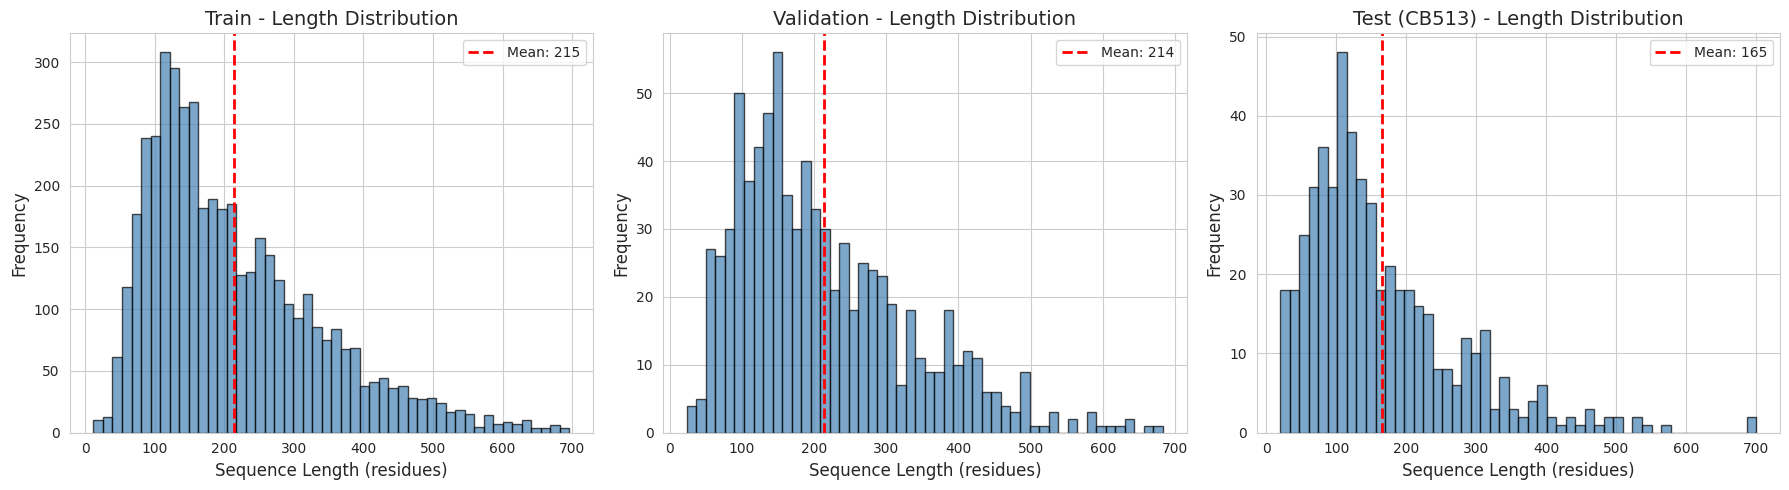

In [ ]:
import os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df, name) in enumerate([
    (train_df, 'Train'),
    (val_df, 'Validation'),
    (test_df, 'Test (CB513)')
]):
    axes[idx].hist(df['length'], bins=50, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[idx].axvline(df['length'].mean(), color='red',
                      linestyle='--', linewidth=2,
                      label=f"Mean: {df['length'].mean():.0f}")
    axes[idx].set_xlabel('Sequence Length (residues)', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].set_title(f'{name} - Length Distribution', fontsize=14)
    axes[idx].legend()

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/length_distribution.png', dpi=300)
plt.show()

In [ ]:
def compute_q3_distribution(df):
    all_labels = ''.join(df['q3_label'].values)
    counts = Counter(all_labels)
    total = sum(counts.values())

    return {
        'H': counts['H'],
        'E': counts['E'],
        'C': counts['C'],
        'H_pct': (counts['H'] / total) * 100,
        'E_pct': (counts['E'] / total) * 100,
        'C_pct': (counts['C'] / total) * 100
    }

print("\nQ3 Label Distribution:")
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    dist = compute_q3_distribution(df)
    print(f"\n{name}:")
    print(f"  H (Helix):  {dist['H']:,} ({dist['H_pct']:.2f}%)")
    print(f"  E (Strand): {dist['E']:,} ({dist['E_pct']:.2f}%)")
    print(f"  C (Coil):   {dist['C']:,} ({dist['C_pct']:.2f}%)")



Q3 Label Distribution:

Train:
  H (Helix):  375,362 (38.61%)
  E (Strand): 221,854 (22.82%)
  C (Coil):   375,051 (38.57%)

Val:
  H (Helix):  67,210 (39.27%)
  E (Strand): 38,693 (22.61%)
  C (Coil):   65,246 (38.12%)

Test:
  H (Helix):  29,648 (34.98%)
  E (Strand): 19,089 (22.52%)
  C (Coil):   36,028 (42.50%)


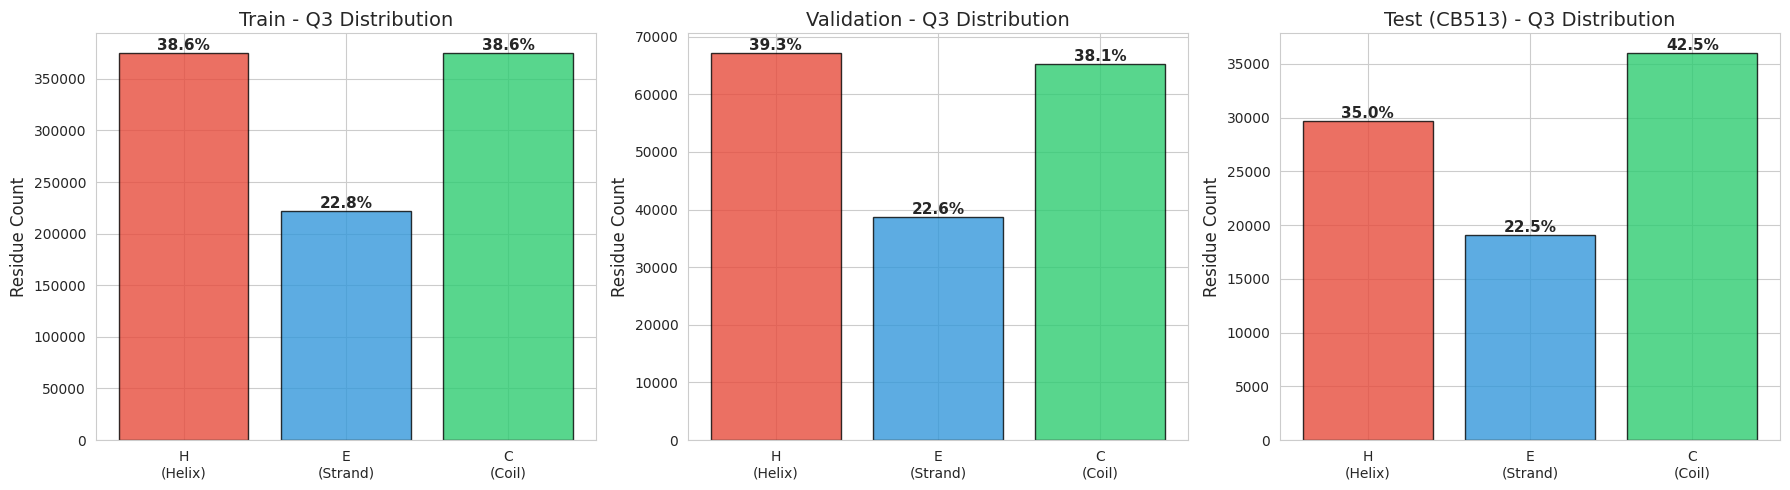

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df, name) in enumerate([
    (train_df, 'Train'),
    (val_df, 'Validation'),
    (test_df, 'Test (CB513)')
]):
    dist = compute_q3_distribution(df)
    labels = ['H\n(Helix)', 'E\n(Strand)', 'C\n(Coil)']
    values = [dist['H'], dist['E'], dist['C']]
    percentages = [dist['H_pct'], dist['E_pct'], dist['C_pct']]
    colors = ['#e74c3c', '#3498db', '#2ecc71']

    bars = axes[idx].bar(labels, values, color=colors,
                          edgecolor='black', alpha=0.8)
    axes[idx].set_ylabel('Residue Count', fontsize=12)
    axes[idx].set_title(f'{name} - Q3 Distribution', fontsize=14)

    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{pct:.1f}%', ha='center', va='bottom',
                      fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('figures/q3_distribution.png', dpi=300)
plt.show()


In [ ]:
print("\n" + "="*80)
print("Sample Sequences with Q3 Labels")
print("="*80)

samples = train_df.sample(5, random_state=42)

for idx, row in samples.iterrows():
    print(f"\n{'─'*80}")
    print(f"Protein ID: {row['protein_id']}")
    print(f"Length: {row['length']} residues")
    print(f"\nSequence (first 70 residues):")
    print(f"  {row['sequence'][:70]}")
    print(f"\nQ3 Labels (first 70 residues):")
    print(f"  {row['q3_label'][:70]}")

    h_count = row['q3_label'].count('H')
    e_count = row['q3_label'].count('E')
    c_count = row['q3_label'].count('C')
    print(f"\nComposition: H={h_count} ({h_count/row['length']*100:.1f}%), "
          f"E={e_count} ({e_count/row['length']*100:.1f}%), "
          f"C={c_count} ({c_count/row['length']*100:.1f}%)")



Sample Sequences with Q3 Labels

────────────────────────────────────────────────────────────────────────────────
Protein ID: cullpdb_4342
Length: 99 residues

Sequence (first 70 residues):
  SWPRFKHECFEEAFVAKWQREEQFSENTSDMAKNHTGARQYCSQQWWMMRHTPMEWDPRPNMSWHASMYR

Q3 Labels (first 70 residues):
  CEEEEEEECCCHHHCEECCCCCCCCCCCEEEEEEEECCCCCCCCCEEEEEEEEEEECCCCCCCCEEEEEE

Composition: H=3 (3.0%), E=55 (55.6%), C=41 (41.4%)

────────────────────────────────────────────────────────────────────────────────
Protein ID: cullpdb_4149
Length: 15 residues

Sequence (first 70 residues):
  LEWNQTMMGMKWQAP

Q3 Labels (first 70 residues):
  CCCCHHHHHHCCCCC

Composition: H=6 (40.0%), E=0 (0.0%), C=9 (60.0%)

────────────────────────────────────────────────────────────────────────────────
Protein ID: cullpdb_5296
Length: 260 residues

Sequence (first 70 residues):
  LMTHMKMFFRHMREKNWQYRHKVENMDSHALDHKNAMEYYKNPNKDHKMHMWIFFFAGFIQWAKKYMKHD

Q3 Labels (first 70 residues):
  CEEEEEECCCCCCCCCCCCCCCHHHHHHHHHHHHH

In [ ]:
def detect_outliers_iqr(df, name):
    Q1 = df['length'].quantile(0.25)
    Q3 = df['length'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df['length'] < lower) | (df['length'] > upper)]
    short = outliers[outliers['length'] < lower]
    long = outliers[outliers['length'] > upper]

    print(f"\n{name}:")
    print(f"  Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
    print(f"  Bounds: [{lower:.0f}, {upper:.0f}]")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"    - Very short (<{lower:.0f}): {len(short)}")
    print(f"    - Very long (>{upper:.0f}): {len(long)}")

    if len(long) > 0:
        print(f"  Longest sequences: {sorted(long['length'].values)[-5:]}")

print("\nOutlier Detection (IQR Method):")
print("="*80)
detect_outliers_iqr(train_df, 'Train')
detect_outliers_iqr(val_df, 'Validation')
detect_outliers_iqr(test_df, 'Test (CB513)')



Outlier Detection (IQR Method):

Train:
  Q1=120, Q3=283, IQR=163
  Bounds: [-124, 528]
  Outliers: 106 (2.34%)
    - Very short (<-124): 0
    - Very long (>528): 106
  Longest sequences: [np.int64(677), np.int64(687), np.int64(691), np.int64(693), np.int64(696)]

Validation:
  Q1=123, Q3=283, IQR=160
  Bounds: [-118, 523]
  Outliers: 15 (1.88%)
    - Very short (<-118): 0
    - Very long (>523): 15
  Longest sequences: [np.int64(628), np.int64(632), np.int64(638), np.int64(664), np.int64(683)]

Test (CB513):
  Q1=88, Q3=213, IQR=124
  Bounds: [-98, 400]
  Outliers: 20 (3.89%)
    - Very short (<-98): 0
    - Very long (>400): 20
  Longest sequences: [np.int64(534), np.int64(544), np.int64(576), np.int64(700), np.int64(700)]


# Embeddings

In [ ]:
import sys
import subprocess
import os

try:
    import onnxruntime as ort
    print("ONNX Runtime is already installed.")
except ImportError:
    print("Installing onnxruntime-gpu...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnxruntime-gpu"])
    print("Installation complete. Restarting runtime...")
    os.kill(os.getpid(), 9)

ONNX Runtime is already installed.


In [ ]:
import onnxruntime as ort

print(f"Version: {ort.__version__}")
print(f"Available Providers: {ort.get_available_providers()}")

Version: 1.23.2
Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [ ]:
import os
import onnxruntime as ort
from transformers import T5Tokenizer
from huggingface_hub import snapshot_download

# 1. Load Tokenizer
print("⏳ Loading Tokenizer...")
tokenizer = T5Tokenizer.from_pretrained(
    "Rostlab/prot_t5_xl_half_uniref50-enc",
    do_lower_case=False,
    legacy=False
)

print("⏳ Locating ONNX Model...")
model_folder = snapshot_download(repo_id="Rostlab/prot-t5-xl-uniref50-enc-onnx")
onnx_path = os.path.join(model_folder, "model.onnx")

# 3. Create Session
print(f"🚀 Creating ONNX Session from: {onnx_path}")
session = ort.InferenceSession(
    onnx_path,
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)

print("✅ Setup Complete. Ready to generate embeddings!")

⏳ Loading Tokenizer...


Invalid model-index. Not loading eval results into CardData.


⏳ Locating ONNX Model...


Fetching 155 files:   0%|          | 0/155 [00:00<?, ?it/s]

🚀 Creating ONNX Session from: /root/.cache/huggingface/hub/models--Rostlab--prot-t5-xl-uniref50-enc-onnx/snapshots/6c74c2e6a99b7b39bf3f9ce632f58e9029dfee9e/model.onnx
✅ Setup Complete. Ready to generate embeddings!


In [ ]:
# NO need to run everytime, it will fetch from drive further.
import pandas as pd
import numpy as np
import os
from tqdm.notebook import tqdm

def generate_embeddings(csv_path, output_dir, session, tokenizer):
    # Check input
    if not os.path.exists(csv_path):
        print(f"❌ Error: Input file not found at {csv_path}")
        return

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    df = pd.read_csv(csv_path)
    print(f"📂 Processing {len(df)} sequences from {csv_path}...")

    # Using tqdm for a nice progress bar
    for i, row in tqdm(df.iterrows(), total=len(df), desc="Generating Embeddings"):
        protein_id = row['protein_id']
        sequence = row['sequence']

        # Skip if file already exists (Resume capability)
        output_file = f"{output_dir}/{protein_id}.npy"
        if os.path.exists(output_file):
            continue

        # 1. Tokenize (Space separated for ProtT5)
        tokenized_seq = " ".join(list(sequence))

        # 2. Replace rare amino acids
        tokenized_seq = tokenized_seq.replace('U', 'X').replace('O', 'X').replace('Z', 'X').replace('B', 'X')

        # 3. Encode
        inputs = tokenizer.encode_plus(
            tokenized_seq,
            add_special_tokens=True,
            padding='max_length',
            max_length=1024,
            truncation=True,
            return_tensors='np'
        )

        input_ids = inputs['input_ids'].astype(np.int64)
        attention_mask = inputs['attention_mask'].astype(np.int64)

        # 4. Inference
        outputs = session.run(
            None,
            {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }
        )

        # 5. Extract & Trim
        embeddings = outputs[0][0]
        seq_len = len(sequence)

        embeddings_trimmed = embeddings[1 : seq_len + 1]

        # 6. Save
        np.save(output_file, embeddings_trimmed.astype(np.float32))

    print(f"✅ Completed: {output_dir}")

# --- Execution ---

print(f"Using Base Path: {base_drive_path}")

# Run for Train
generate_embeddings(
    csv_path=f'{base_drive_path}/data/processed/train.csv',
    output_dir=f'{base_drive_path}/embeddings/train',
    session=session,
    tokenizer=tokenizer
)

# Run for Val
generate_embeddings(
    csv_path=f'{base_drive_path}/data/processed/val.csv',
    output_dir=f'{base_drive_path}/embeddings/val',
    session=session,
    tokenizer=tokenizer
)

Using Base Path: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project
📂 Processing 4529 sequences from /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/data/processed/train.csv...


Generating Embeddings:   0%|          | 0/4529 [00:00<?, ?it/s]

✅ Completed: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/embeddings/train
📂 Processing 800 sequences from /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/data/processed/val.csv...


Generating Embeddings:   0%|          | 0/800 [00:00<?, ?it/s]

✅ Completed: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/embeddings/val


In [ ]:
import numpy as np
import glob
import os

base_drive_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'

def verify_embeddings(folder_name):
    search_path = os.path.join(base_drive_path, "embeddings", folder_name, "*.npy")
    files = glob.glob(search_path)

    if len(files) == 0:
        print(f"❌ No files found in {folder_name}!")
        return

    random_file = np.random.choice(files)
    data = np.load(random_file)

    print(f"🔍 Verifying {folder_name}...")
    print(f"   - Found {len(files)} files")
    print(f"   - Sample file: {os.path.basename(random_file)}")
    print(f"   - Shape: {data.shape}")

    if data.ndim == 2 and data.shape[1] == 1024:
        print("   - ✅ Dimension Check: PASSED (1024 features)")
    else:
        print(f"   - ❌ Dimension Check: FAILED! Found {data.shape}")

# Run verification
verify_embeddings("train")
verify_embeddings("val")

🔍 Verifying train...
   - Found 4530 files
   - Sample file: cullpdb_1783.npy
   - Shape: (162, 1024)
   - ✅ Dimension Check: PASSED (1024 features)
🔍 Verifying val...
   - Found 800 files
   - Sample file: cullpdb_2931.npy
   - Shape: (153, 1024)
   - ✅ Dimension Check: PASSED (1024 features)


In [ ]:
import numpy as np

# Load one embedding
emb = np.load(f'{base_drive_path}/embeddings/train/cullpdb_0.npy')
print(f"Shape: {emb.shape}")
print(f"Dtype: {emb.dtype}")
print(f"Range: [{emb.min():.4f}, {emb.max():.4f}]")


Shape: (315, 1024)
Dtype: float32
Range: [-1.2842, 1.1094]


In [ ]:
import numpy as np

def load_embedding(protein_id, embedding_dir=f'{base_drive_path}/embeddings/train/'):
    path = f"{embedding_dir}/{protein_id}.npy"
    emb = np.load(path)
    return emb

# Usage
emb = load_embedding('cullpdb_0')
print(f"Loaded embedding shape: {emb.shape}")


Loaded embedding shape: (315, 1024)


In [ ]:
def load_embeddings_batch(protein_ids, embedding_dir=f'{base_drive_path}/embeddings/train/'):
    """Load multiple embeddings, handle variable lengths."""
    embeddings = []
    lengths = []

    for pid in protein_ids:
        emb = np.load(f"{embedding_dir}/{pid}.npy")
        embeddings.append(emb)
        lengths.append(emb.shape[0])

    return embeddings, lengths


In [ ]:
import torch

def pad_embeddings(embeddings, max_len=700):

    batch_size = len(embeddings)
    padded = torch.zeros((batch_size, max_len, 1024), dtype=torch.float32)

    for i, emb in enumerate(embeddings):
        seq_len = min(emb.shape[0], max_len)
        padded[i, :seq_len, :] = torch.from_numpy(emb[:seq_len])

    return padded


In [ ]:
import os

src_dir = os.path.join(base_drive_path, "src", "train")
os.makedirs(src_dir, exist_ok=True)

model_file_path = os.path.join(src_dir, "model.py")

model_code = """
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class ProteinBiLSTMClassifier(nn.Module):
    def __init__(self, embedding_dim=1024, hidden_dim=256, num_layers=1,
                 dropout=0.3, num_classes=3):
        super().__init__()

        # 1. BiLSTM Layer
        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 2. Dropout
        self.dropout = nn.Dropout(dropout)

        # 3. Classifier Head (Input: 512 -> Output: 3)
        self.classifier = nn.Linear(2 * hidden_dim, num_classes)

    def forward(self, embeddings, lengths):
        # Pack sequence to ignore padding
        packed = pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        # Forward pass
        lstm_out_packed, _ = self.bilstm(packed)

        # Unpack
        lstm_out, _ = pad_packed_sequence(lstm_out_packed, batch_first=True)

        # Classify
        out = self.dropout(lstm_out)
        logits = self.classifier(out)

        return logits
"""

# Write to file
with open(model_file_path, "w") as f:
    f.write(model_code)

print(f"✅ Model saved to: {model_file_path}")

✅ Model saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/src/train/model.py


In [ ]:
import os

# Define the file path
dataset_file_path = os.path.join(base_drive_path, "src", "train", "dataset.py")

dataset_code = """
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

# Q3 Label Mapping
Q3_TO_IDX = {'H': 0, 'E': 1, 'C': 2}
IDX_TO_Q3 = {0: 'H', 1: 'E', 2: 'C'}

class ProteinSecondaryStructureDataset(Dataset):
    def __init__(self, csv_path, embedding_dir, max_length=700):
        self.df = pd.read_csv(csv_path)
        self.embedding_dir = embedding_dir
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        protein_id = row['protein_id']
        q3_seq = row['q3_label']

        # 1. Load Embedding
        emb_path = os.path.join(self.embedding_dir, f"{protein_id}.npy")
        # Safety check for file existence
        if not os.path.exists(emb_path):
            raise FileNotFoundError(f"Embedding not found: {emb_path}")

        embedding = np.load(emb_path) # Shape: (L, 1024)

        # 2. Convert Labels to Indices
        # 'HHEC...' -> [0, 0, 1, 2...]
        label_indices = [Q3_TO_IDX[char] for char in q3_seq]
        label_tensor = torch.tensor(label_indices, dtype=torch.long)

        # 3. Truncate if necessary (Safety cap)
        if len(embedding) > self.max_length:
            embedding = embedding[:self.max_length]
            label_tensor = label_tensor[:self.max_length]

        return {
            'embedding': torch.from_numpy(embedding),
            'label': label_tensor,
            'length': len(embedding),
            'id': protein_id
        }

def collate_fn(batch):

    # 1. Sort by length (descending) - Required for pack_padded_sequence
    batch.sort(key=lambda x: x['length'], reverse=True)

    embeddings = [item['embedding'] for item in batch]
    labels = [item['label'] for item in batch]
    lengths = torch.tensor([item['length'] for item in batch], dtype=torch.long)
    ids = [item['id'] for item in batch]

    # 2. Pad Embeddings
    # Result: (batch_size, max_len_in_batch, 1024)
    padded_embeddings = torch.nn.utils.rnn.pad_sequence(
        embeddings, batch_first=True, padding_value=0.0
    )

    # 3. Pad Labels
    # Result: (batch_size, max_len_in_batch)
    # Use -100 as padding value (Standard PyTorch ignore_index)
    padded_labels = torch.nn.utils.rnn.pad_sequence(
        labels, batch_first=True, padding_value=-100
    )

    # 4. Create Mask (1 for real data, 0 for padding)
    mask = torch.zeros_like(padded_labels, dtype=torch.float)
    for i, length in enumerate(lengths):
        mask[i, :length] = 1.0

    return {
        'embeddings': padded_embeddings,
        'labels': padded_labels,
        'masks': mask,
        'lengths': lengths,
        'protein_ids': ids
    }

def create_dataloaders(train_csv, val_csv, train_emb_dir, val_emb_dir, batch_size=4):
    train_ds = ProteinSecondaryStructureDataset(train_csv, train_emb_dir)
    val_ds = ProteinSecondaryStructureDataset(val_csv, val_emb_dir)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0
    )

    return train_loader, val_loader
"""

with open(dataset_file_path, "w") as f:
    f.write(dataset_code)

print(f"✅ Dataset file saved to: {dataset_file_path}")

✅ Dataset file saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/src/train/dataset.py


In [ ]:
import os
utils_file_path = os.path.join(base_drive_path, "src", "train", "train_utils.py")

utils_code = """
import torch
import torch.nn as nn
import numpy as np
import shutil
import os

class MaskedCrossEntropyLoss(nn.Module):
    \"\"\"
    CrossEntropyLoss that ignores padded residues (where mask == 0).
    \"\"\"
    def __init__(self):
        super(MaskedCrossEntropyLoss, self).__init__()
        # reduction='none' allows us to manually mask before averaging
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, labels, masks):
        \"\"\"
        Args:
            logits: (batch_size, seq_len, num_classes)
            labels: (batch_size, seq_len)
            masks:  (batch_size, seq_len) - 1.0 for real, 0.0 for padding
        Returns:
            masked_loss: scalar tensor
        \"\"\"
        # Flatten tensors for CrossEntropyLoss
        batch_size, seq_len, num_classes = logits.shape

        logits_flat = logits.view(-1, num_classes)
        labels_flat = labels.view(-1)
        masks_flat = masks.view(-1)

        # Compute raw loss (element-wise)
        raw_loss = self.ce_loss(logits_flat, labels_flat)

        # Apply mask (multiply padding losses by 0)
        masked_loss = raw_loss * masks_flat

        # Average only over real residues (sum_loss / sum_mask)
        # Add epsilon to avoid division by zero
        loss = masked_loss.sum() / (masks_flat.sum() + 1e-8)

        return loss

def compute_q3_accuracy(logits, labels, masks):
    \"\"\"
    Computes Q3 Accuracy ignoring padding.
    \"\"\"
    with torch.no_grad():
        # Get predictions (argmax over class dim)
        preds = torch.argmax(logits, dim=2)  # (batch, seq_len)

        # Check correctness
        correct = (preds == labels).float()

        # Apply mask (ignore padding)
        correct_masked = correct * masks

        # Accuracy = correct_real_residues / total_real_residues
        accuracy = correct_masked.sum() / (masks.sum() + 1e-8)

    return accuracy.item() * 100

def save_checkpoint(state, is_best, checkpoint_dir='models'):
    \"\"\"Saves model state and creates a copy if it's the best model.\"\"\"
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Save latest checkpoint
    filename = os.path.join(checkpoint_dir, 'checkpoint_latest.pt')
    torch.save(state, filename)

    # If best, copy to best_model.pt
    if is_best:
        best_filename = os.path.join(checkpoint_dir, 'best_model.pt')
        shutil.copyfile(filename, best_filename)
        print(f"  ⭐ Saved new best model to {best_filename}")
"""

with open(utils_file_path, "w") as f:
    f.write(utils_code)

print(f"✅ Utils file saved to: {utils_file_path}")

✅ Utils file saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/src/train/train_utils.py


In [ ]:
import sys
if base_drive_path not in sys.path:
    sys.path.insert(0, base_drive_path)

print("🔍 Verifying Modules...")

try:
    from src.train.model import ProteinBiLSTMClassifier
    print("  ✅ Model module imported successfully")
except ImportError as e:
    print(f"  ❌ Failed to import Model: {e}")

try:
    from src.train.dataset import create_dataloaders
    print("  ✅ Dataset module imported successfully")
except ImportError as e:
    print(f"  ❌ Failed to import Dataset: {e}")

try:
    from src.train.train_utils import MaskedCrossEntropyLoss, compute_q3_accuracy
    print("  ✅ Utils module imported successfully")
except ImportError as e:
    print(f"  ❌ Failed to import Utils: {e}")

print("\n🚀 Phase 2 Infrastructure Ready for Training!")

🔍 Verifying Modules...
  ✅ Model module imported successfully
  ✅ Dataset module imported successfully
  ✅ Utils module imported successfully

🚀 Phase 2 Infrastructure Ready for Training!


In [ ]:
import os

# Define the file path
train_script_path = os.path.join(base_drive_path, "src", "train", "train.py")

train_code = """
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
import json
import time
from tqdm import tqdm

# Import our custom modules
from src.train.model import ProteinBiLSTMClassifier
from src.train.dataset import create_dataloaders
from src.train.train_utils import MaskedCrossEntropyLoss, compute_q3_accuracy, save_checkpoint

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    # Progress bar for the epoch
    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        # Move data to device (CPU/GPU)
        embeddings = batch['embeddings'].to(device)
        labels = batch['labels'].to(device)
        masks = batch['masks'].to(device)
        lengths = batch['lengths']

        # 1. Forward Pass
        logits = model(embeddings, lengths)

        # 2. Compute Loss (Masked)
        loss = loss_fn(logits, labels, masks)

        # 3. Backward Pass
        optimizer.zero_grad()
        loss.backward()

        # 4. Gradient Clipping (Prevent explosion in LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Update Weights
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(loader)

def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for batch in loader:
            embeddings = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)
            masks = batch['masks'].to(device)
            lengths = batch['lengths']

            logits = model(embeddings, lengths)
            loss = loss_fn(logits, labels, masks)
            acc = compute_q3_accuracy(logits, labels, masks)

            total_loss += loss.item()
            total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

def main():
    # --- Configuration ---
    config = {
        'batch_size': 4,
        'epochs': 20,
        'lr': 1e-3,
        'patience': 5,
        'hidden_dim': 256,
        'dropout': 0.3
    }

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Training on Device: {device}")

    # Paths (Assumes running from project root or Colab with drive mounted)
    base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'

    # 1. Load Data
    print("⏳ Loading Datasets...")
    train_loader, val_loader = create_dataloaders(
        train_csv=os.path.join(base_path, 'data/processed/train.csv'),
        val_csv=os.path.join(base_path, 'data/processed/val.csv'),
        train_emb_dir=os.path.join(base_path, 'embeddings/train'),
        val_emb_dir=os.path.join(base_path, 'embeddings/val'),
        batch_size=config['batch_size']
    )

    # 2. Initialize Model
    print("🧠 Initializing BiLSTM Model...")
    model = ProteinBiLSTMClassifier(
        hidden_dim=config['hidden_dim'],
        dropout=config['dropout']
    ).to(device)

    # 3. Setup Optimizer & Loss
    optimizer = AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    loss_fn = MaskedCrossEntropyLoss()

    # 4. Training Loop
    best_val_acc = 0.0
    patience_counter = 0
    logs = []

    print(f"🔥 Starting Training for {config['epochs']} Epochs...")

    for epoch in range(config['epochs']):
        start_time = time.time()

        # Train & Validate
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validate(model, val_loader, loss_fn, device)

        # Logging
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.0f}s")

        # LR Scheduling
        scheduler.step(val_acc)

        # Checkpointing
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1

        save_checkpoint(
            {
                'epoch': epoch + 1,
                'state_dict': model.state_dict(),
                'best_acc': best_val_acc,
                'optimizer': optimizer.state_dict(),
            },
            is_best,
            checkpoint_dir=os.path.join(base_path, 'models')
        )

        # Save logs
        logs.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        with open(os.path.join(base_path, 'logs', 'training_log.json'), 'w') as f:
            json.dump(logs, f)

        # Early Stopping
        if patience_counter >= config['patience']:
            print(f"🛑 Early stopping triggered after {config['patience']} epochs without improvement.")
            break

    print(f"✅ Training Complete. Best Validation Accuracy: {best_val_acc:.2f}%")

if __name__ == '__main__':
    base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
    os.makedirs(os.path.join(base_path, 'models'), exist_ok=True)
    os.makedirs(os.path.join(base_path, 'logs'), exist_ok=True)
    main()
"""

with open(train_script_path, "w") as f:
    f.write(train_code)

print(f"✅ Training script saved to: {train_script_path}")

✅ Training script saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/src/train/train.py


# Model Training

In [ ]:
import pandas as pd
import numpy as np
import os

def check_dataset(csv_path, embedding_dir, dataset_name=''):
    """Verify dataset integrity."""
    print(f"\n{'='*70}")
    print(f"Checking {dataset_name} dataset")
    print(f"{'='*70}")

    df = pd.read_csv(csv_path)
    print(f"Total proteins: {len(df)}")

    # Check for missing embeddings
    missing = []
    bad_shapes = []
    bad_labels = []

    for idx, row in df.iterrows():
        protein_id = row['protein_id']
        emb_path = f"{embedding_dir}/{protein_id}.npy"

        # Check file exists
        if not os.path.exists(emb_path):
            missing.append(protein_id)
            continue

        # Check shape
        emb = np.load(emb_path)
        if emb.ndim != 2 or emb.shape[1] != 1024:
            bad_shapes.append((protein_id, emb.shape))

        # Check label length
        if len(row['sequence']) != len(row['q3_label']):
            bad_labels.append((protein_id, len(row['sequence']), len(row['q3_label'])))

        # Check label chars
        bad_chars = set(row['q3_label']) - {'H', 'E', 'C'}
        if bad_chars:
            bad_labels.append((protein_id, f"Bad chars: {bad_chars}"))

    # Report
    print(f"✓ Files checked: {len(df) - len(missing)}/{len(df)}")
    if missing:
        print(f"✗ Missing: {len(missing)} files")
        for m in missing[:5]:
            print(f"  - {m}")
    else:
        print(f"✓ All embeddings found")

    if bad_shapes:
        print(f"✗ Bad shapes: {len(bad_shapes)}")
        for pid, shape in bad_shapes[:3]:
            print(f"  - {pid}: {shape}")
    else:
        print(f"✓ All embeddings have shape (L, 1024)")

    if bad_labels:
        print(f"✗ Bad labels: {len(bad_labels)}")
        for item in bad_labels[:3]:
            print(f"  - {item}")
    else:
        print(f"✓ All labels valid")

    return len(missing) == 0 and len(bad_shapes) == 0 and len(bad_labels) == 0


# Updated execution lines to ensure paths are correct
train_ok = check_dataset(
    f'{base_drive_path}/data/processed/train.csv',
    f'{base_drive_path}/embeddings/train',
    'TRAIN'
)

val_ok = check_dataset(
    f'{base_drive_path}/data/processed/val.csv',
    f'{base_drive_path}/embeddings/val',
    'VALIDATION'
)

if train_ok and val_ok:
    print(f"\n{'✓'*35} ALL CHECKS PASSED {'✓'*35}")
else:
    print(f"\n✗ ERRORS FOUND - FIX BEFORE TRAINING")
    raise RuntimeError("Fix dataset errors before proceeding")



Checking TRAIN dataset
Total proteins: 4529
✓ Files checked: 4529/4529
✓ All embeddings found
✓ All embeddings have shape (L, 1024)
✓ All labels valid

Checking VALIDATION dataset
Total proteins: 800
✓ Files checked: 800/800
✓ All embeddings found
✓ All embeddings have shape (L, 1024)
✓ All labels valid

✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ ALL CHECKS PASSED ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓


In [ ]:
from src.train.dataset import create_dataloaders
import torch

base_drive_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'

print("🔍 Inspecting DataLoader...")

train_loader, val_loader = create_dataloaders(
    f'{base_drive_path}/data/processed/train.csv',
    f'{base_drive_path}/data/processed/val.csv',
    f'{base_drive_path}/embeddings/train',
    f'{base_drive_path}/embeddings/val',
    batch_size=4
)

# Inspect one batch
try:
    batch = next(iter(train_loader))

    print(f"✅ Batch loaded successfully")
    print(f"   Batch keys: {batch.keys()}")
    print(f"   Embeddings: {batch['embeddings'].shape} (Should be [4, L, 1024])")
    print(f"   Labels:     {batch['labels'].shape}     (Should be [4, L])")
    print(f"   Masks:      {batch['masks'].shape}      (Should be [4, L])")
    print(f"   Lengths:    {batch['lengths']}")

    # Verify mask correctness
    assert torch.all((batch['masks'] == 0) | (batch['masks'] == 1)), "Mask not binary!"
    assert batch['masks'].sum() > 0, "Mask all zeros!"

    print("\n✓ DataLoader validation PASSED")

except Exception as e:
    print(f"\n❌ DataLoader Failed: {e}")
    print("Check if your CSV paths are correct and 'data/processed' exists.")

🔍 Inspecting DataLoader...
✅ Batch loaded successfully
   Batch keys: dict_keys(['embeddings', 'labels', 'masks', 'lengths', 'protein_ids'])
   Embeddings: torch.Size([4, 453, 1024]) (Should be [4, L, 1024])
   Labels:     torch.Size([4, 453])     (Should be [4, L])
   Masks:      torch.Size([4, 453])      (Should be [4, L])
   Lengths:    tensor([453, 302, 185, 109])

✓ DataLoader validation PASSED


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import pandas as pd
import os
import sys
import time
import json
import importlib

# =====================================================
# 1. SETUP PATHS & CONFIGURATION
# =====================================================
base_drive_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'

if base_drive_path not in sys.path:
    sys.path.append(base_drive_path)

os.makedirs(os.path.join(base_drive_path, 'models'), exist_ok=True)
os.makedirs(os.path.join(base_drive_path, 'logs'), exist_ok=True)

CONFIG = {
    'batch_size': 4,
    'epochs': 20,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'patience_scheduler': 3,
    'patience_earlystop': 5,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

print(f"🚀 Training Configuration Loaded.")
print(f"   Device: {CONFIG['device']}")
print(f"   Root: {base_drive_path}")

# =====================================================
# 2. IMPORTS (With Force Reload)
# =====================================================
try:
    import src.train.model
    import src.train.dataset
    import src.train.train_utils

    importlib.reload(src.train.model)
    importlib.reload(src.train.dataset)
    importlib.reload(src.train.train_utils)

    from src.train.model import ProteinBiLSTMClassifier
    from src.train.dataset import create_dataloaders
    from src.train.train_utils import MaskedCrossEntropyLoss, compute_q3_accuracy
    print("✅ Modules imported and reloaded successfully.")
except ImportError as e:
    print(f"❌ CRITICAL ERROR: Could not import modules.")
    print(f"   Error details: {e}")
    print("   Please ensure 'src/train/model.py', 'dataset.py', and 'train_utils.py' exist.")
    raise e

# =====================================================
# 3. HELPER CLASSES
# =====================================================
class EarlyStopping:
    """Stops training if validation metric doesn't improve after `patience` epochs."""
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
        elif current_score > (self.best_score + self.min_delta):
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# =====================================================
# 4. TRAINING & VALIDATION LOOPS
# =====================================================
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in loader:
        # Move data to Device
        embeddings = batch['embeddings'].to(device)
        labels = batch['labels'].to(device)
        masks = batch['masks'].to(device)
        lengths = batch['lengths']

        # Forward Pass
        logits = model(embeddings, lengths)
        loss = loss_fn(logits, labels, masks)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in loader:
            embeddings = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)
            masks = batch['masks'].to(device)
            lengths = batch['lengths']

            logits = model(embeddings, lengths)

            # Compute Loss & Accuracy
            loss = loss_fn(logits, labels, masks)
            acc = compute_q3_accuracy(logits, labels, masks)

            total_loss += loss.item()
            total_acc += acc
            num_batches += 1

    return total_loss / num_batches, total_acc / num_batches

# =====================================================
# 5. MAIN EXECUTION PIPELINE
# =====================================================
print("\n⏳ Loading DataLoaders...")

train_loader, val_loader = create_dataloaders(
    f'{base_drive_path}/data/processed/train.csv',
    f'{base_drive_path}/data/processed/val.csv',
    f'{base_drive_path}/embeddings/train',
    f'{base_drive_path}/embeddings/val',
    batch_size=CONFIG['batch_size']
)
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

# B. Initialize Model
print("🧠 Initializing BiLSTM Model...")
model = ProteinBiLSTMClassifier(
    embedding_dim=1024,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3,
    num_classes=3
).to(CONFIG['device'])

optimizer = AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
loss_fn = MaskedCrossEntropyLoss()

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                              patience=CONFIG['patience_scheduler'])

# Early Stopping: Monitors Validation Accuracy
early_stopping = EarlyStopping(patience=CONFIG['patience_earlystop'])

# D. Training Loop
best_val_acc = 0.0
history = []

print(f"\n🔥 STARTING TRAINING ({CONFIG['epochs']} Epochs)")
print("="*65)

for epoch in range(CONFIG['epochs']):
    start_time = time.time()

    # --- 1. Train ---
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, CONFIG['device'])

    # --- 2. Validate ---
    val_loss, val_acc = validate(model, val_loader, loss_fn, CONFIG['device'])

    # --- 3. Logging & Display ---
    elapsed = time.time() - start_time
    lr_curr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
          f"Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"Time: {elapsed:.0f}s")

    history.append({
        'epoch': epoch+1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'lr': lr_curr
    })

    # --- 4. Checkpointing ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(base_drive_path, 'models/best_model.pt'))
        print(f"   ⭐ New Best Model Saved! ({best_val_acc:.2f}%)")

    # Save Last Epoch (for recovery)
    torch.save(model.state_dict(), os.path.join(base_drive_path, 'models/last_epoch.pt'))

    # --- 5. Scheduler & Early Stopping ---
    scheduler.step(val_acc)
    early_stopping(val_acc)

    if early_stopping.early_stop:
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs.")
        break

# =====================================================
# 6. FINAL OUTPUT & LOG SAVING
# =====================================================
print("\n" + "="*65)
print("✅ TRAINING COMPLETE")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")

# Save CSV Log
log_path_csv = os.path.join(base_drive_path, 'logs/training_log.csv')
pd.DataFrame(history).to_csv(log_path_csv, index=False)
print(f"📝 Logs saved to: {log_path_csv}")

# Save JSON Log (Metadata)
log_path_json = os.path.join(base_drive_path, 'logs/training_log.json')
with open(log_path_json, 'w') as f:
    json.dump({'config': str(CONFIG), 'history': history, 'best_acc': best_val_acc}, f, indent=4)

print("="*65)

🚀 Training Configuration Loaded.
   Device: cuda
   Root: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project
✅ Modules imported and reloaded successfully.

⏳ Loading DataLoaders...
   Train batches: 1133
   Val batches:   200
🧠 Initializing BiLSTM Model...

🔥 STARTING TRAINING (20 Epochs)
Epoch 01/20 | Loss: 0.7707 | Val Loss: 0.7167 | Val Acc: 68.80% | Time: 86s
   ⭐ New Best Model Saved! (68.80%)
Epoch 02/20 | Loss: 0.6831 | Val Loss: 0.6927 | Val Acc: 69.75% | Time: 84s
   ⭐ New Best Model Saved! (69.75%)
Epoch 03/20 | Loss: 0.6369 | Val Loss: 0.6841 | Val Acc: 70.44% | Time: 86s
   ⭐ New Best Model Saved! (70.44%)
Epoch 04/20 | Loss: 0.5877 | Val Loss: 0.6958 | Val Acc: 70.25% | Time: 87s
Epoch 05/20 | Loss: 0.5362 | Val Loss: 0.7154 | Val Acc: 69.85% | Time: 87s
Epoch 06/20 | Loss: 0.4853 | Val Loss: 0.7476 | Val Acc: 69.65% | Time: 87s
Epoch 07/20 | Loss: 0.4366 | Val Loss: 0.7978 | Val Acc: 69.07% | Time: 86s
Epoch 08/20 | Loss: 0.3660 | Val Loss: 0.8675 | Val Acc: 6

# Evaluation

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import onnxruntime as ort
from transformers import T5Tokenizer
from huggingface_hub import snapshot_download

# ==========================================
# 1. SETUP PATHS
# ==========================================
base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
csv_path = os.path.join(base_path, 'data/processed/test_cb513.csv')
emb_test_dir = os.path.join(base_path, 'embeddings/test_cb513')

# Ensure directories exist
os.makedirs(emb_test_dir, exist_ok=True)
os.makedirs(os.path.join(base_path, 'results'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'reports'), exist_ok=True)

# ==========================================
# 2. CHECK & GENERATE EMBEDDINGS
# ==========================================
if not os.path.exists(csv_path):
    print(f"❌ Error: Test CSV not found at {csv_path}")
else:
    df_test = pd.read_csv(csv_path)
    existing_embs = [f for f in os.listdir(emb_test_dir) if f.endswith('.npy')]

    if len(existing_embs) >= len(df_test):
        print(f"✅ CB513 Embeddings already exist ({len(existing_embs)} files). Skipping generation.")
    else:
        print(f"⚠️ Found {len(existing_embs)}/{len(df_test)} embeddings. Generating missing files...")

        try:
            print("⏳ Loading Tokenizer...")
            tokenizer = T5Tokenizer.from_pretrained(
                "Rostlab/prot_t5_xl_half_uniref50-enc",
                do_lower_case=False,
                legacy=False
            )

            print("⏳ Locating ONNX Model via Snapshot Download...")
            model_folder = snapshot_download(repo_id="Rostlab/prot-t5-xl-uniref50-enc-onnx")
            onnx_path = os.path.join(model_folder, "model.onnx")

            print(f"🚀 Creating ONNX Session from: {onnx_path}")
            # Check for GPU
            providers = ['CUDAExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']
            session = ort.InferenceSession(onnx_path, providers=providers)

            print("▶️ Starting Embedding Generation...")
            count = 0
            for idx, row in df_test.iterrows():
                pid = row['protein_id']
                seq = row['sequence']
                save_path = os.path.join(emb_test_dir, f"{pid}.npy")

                if os.path.exists(save_path):
                    continue

                # Tokenize
                seq_spaced = " ".join(list(seq))
                inputs = tokenizer.encode_plus(
                    seq_spaced, add_special_tokens=True, padding="max_length",
                    max_length=1024, truncation=True, return_tensors='np'
                )

                input_ids = inputs['input_ids'].astype(np.int64)
                attention_mask = inputs['attention_mask'].astype(np.int64)

                # Inference
                outputs = session.run(None, {'input_ids': input_ids, 'attention_mask': attention_mask})
                embedding = outputs[0][0] # (1024, 1024)

                # Trim padding & CLS token -> (L, 1024)
                seq_len = len(seq)
                emb_trimmed = embedding[1 : seq_len+1]

                np.save(save_path, emb_trimmed.astype(np.float32))
                count += 1
                if count % 50 == 0: print(f"   Processed {count} proteins...")

            print(f"✅ Generated {count} new embeddings.")

        except Exception as e:
            print(f"❌ Error during embedding generation: {e}")
            print("Try installing dependencies: !pip install huggingface_hub onnxruntime-gpu")

⚠️ Found 0/514 embeddings. Generating missing files...
⏳ Loading Tokenizer...


Invalid model-index. Not loading eval results into CardData.


⏳ Locating ONNX Model via Snapshot Download...


Fetching 155 files:   0%|          | 0/155 [00:00<?, ?it/s]

🚀 Creating ONNX Session from: /root/.cache/huggingface/hub/models--Rostlab--prot-t5-xl-uniref50-enc-onnx/snapshots/6c74c2e6a99b7b39bf3f9ce632f58e9029dfee9e/model.onnx
▶️ Starting Embedding Generation...
   Processed 50 proteins...
   Processed 100 proteins...
   Processed 150 proteins...
   Processed 200 proteins...
   Processed 250 proteins...
   Processed 300 proteins...
   Processed 350 proteins...
   Processed 400 proteins...
   Processed 450 proteins...
   Processed 500 proteins...
✅ Generated 514 new embeddings.


In [ ]:
import os

base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
save_path = os.path.join(base_path, 'src', 'evaluation.py')

code_content = """
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

class InferenceEngine:
    def __init__(self, model_path, device='cpu'):
        self.device = device
        self.model = None
        self.model_path = model_path

    def load_model(self, model_class, **model_kwargs):
        self.model = model_class(**model_kwargs).to(self.device)
        state_dict = torch.load(self.model_path, map_location=self.device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        print(f"✓ Model loaded from {self.model_path}")

    def predict_batch(self, embeddings, lengths):
        with torch.no_grad():
            logits = self.model(embeddings.to(self.device), lengths)
            predictions = torch.argmax(logits, dim=2)
            probabilities = torch.softmax(logits, dim=2)
        return logits.cpu(), predictions.cpu(), probabilities.cpu()

    def predict_dataset(self, dataloader):
        all_predictions = []
        all_labels = []
        all_probabilities = []
        all_lengths = []
        all_protein_ids = []

        print(f"🚀 Starting Inference on {len(dataloader)} batches...")
        for batch_idx, batch in enumerate(dataloader):
            embeddings = batch['embeddings']
            labels = batch['labels']
            lengths = batch['lengths']
            protein_ids = batch['protein_ids']

            logits, pred_classes, probs = self.predict_batch(embeddings, lengths)

            for i in range(embeddings.shape[0]):
                seq_len = lengths[i].item()
                pred_seq = pred_classes[i, :seq_len].numpy()
                label_seq = labels[i, :seq_len].numpy()
                prob_seq = probs[i, :seq_len].numpy()

                all_predictions.append(pred_seq)
                all_labels.append(label_seq)
                all_probabilities.append(prob_seq)
                all_lengths.append(seq_len)
                all_protein_ids.append(protein_ids[i])

        return {
            'predictions': all_predictions,
            'labels': all_labels,
            'probabilities': all_probabilities,
            'lengths': all_lengths,
            'protein_ids': all_protein_ids,
        }

class MetricsComputer:
    def flatten_predictions(self, predictions_list):
        return np.concatenate(predictions_list)

    def compute_all_metrics(self, predictions_list, labels_list):
        pred_flat = self.flatten_predictions(predictions_list)
        label_flat = self.flatten_predictions(labels_list)

        # Accuracy
        correct = (pred_flat == label_flat).astype(np.float32)
        q3_acc = correct.mean() * 100

        # Per-class
        per_class_acc = {}
        for idx, name in enumerate(['H', 'E', 'C']):
            mask = (label_flat == idx)
            if mask.sum() > 0:
                per_class_acc[name] = ((pred_flat[mask] == idx).sum() / mask.sum()) * 100
            else:
                per_class_acc[name] = 0.0

        # Confusion Matrix
        cm = confusion_matrix(label_flat, pred_flat, labels=[0, 1, 2])

        # Precision/Recall/F1
        precision, recall, f1, _ = precision_recall_fscore_support(
            label_flat, pred_flat, labels=[0, 1, 2], average=None
        )

        metrics = {
            'q3_accuracy': q3_acc,
            'per_class_accuracy': per_class_acc,
            'confusion_matrix': cm,
            'precision_recall_f1': {
                'per_class': {
                    'H': {'precision': precision[0], 'recall': recall[0], 'f1': f1[0]},
                    'E': {'precision': precision[1], 'recall': recall[1], 'f1': f1[1]},
                    'C': {'precision': precision[2], 'recall': recall[2], 'f1': f1[2]},
                },
                'macro': {
                    'precision': precision.mean(),
                    'recall': recall.mean(),
                    'f1': f1.mean(),
                }
            }
        }
        return metrics

class VisualizationGenerator:
    @staticmethod
    def plot_confusion_matrix(cm, output_path):
        labels = ['H (Helix)', 'E (Strand)', 'C (Coil)']
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted Class')
        plt.ylabel('True Class')
        plt.title('Confusion Matrix - CB513')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        plt.close()

    @staticmethod
    def plot_per_class_accuracy(per_class_acc, output_path):
        classes = list(per_class_acc.keys())
        accuracies = list(per_class_acc.values())
        plt.figure(figsize=(8, 5))
        bars = plt.bar(classes, accuracies, color=['#e74c3c', '#3498db', '#2ecc71'])
        plt.ylabel('Accuracy (%)')
        plt.ylim([0, 100])
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        plt.close()

    @staticmethod
    def plot_accuracy_vs_length(predictions_list, labels_list, lengths_list, output_path):
        accuracies = []
        lengths = []
        for pred, label, length in zip(predictions_list, labels_list, lengths_list):
            acc = (pred == label).mean() * 100
            accuracies.append(acc)
            lengths.append(length)

        length_bins = [0, 100, 200, 300, 500, 1000]
        bin_accs = []
        bin_labels = []

        for i in range(len(length_bins) - 1):
            mask = (np.array(lengths) >= length_bins[i]) & (np.array(lengths) < length_bins[i+1])
            if mask.sum() > 0:
                bin_accs.append(np.array(accuracies)[mask].mean())
                bin_labels.append(f"{length_bins[i]}-{length_bins[i+1]}")

        plt.figure(figsize=(10, 6))
        plt.plot(bin_labels, bin_accs, 'o-', linewidth=2, markersize=8, color='#3498db')
        plt.ylabel('Accuracy (%)')
        plt.xlabel('Sequence Length')
        plt.title('Q3 Accuracy vs Sequence Length')
        plt.ylim([0, 100])
        plt.grid(alpha=0.3)
        plt.tight_layout()
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        plt.close()

def generate_evaluation_report(metrics, output_path):
    report = f\"\"\"# CB513 Final Evaluation Report

## 📊 Summary
- **Overall Q3 Accuracy:** {metrics['q3_accuracy']:.2f}%

## 🎯 Per-Class Metrics
| Class | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| **Helix (H)** | {metrics['per_class_accuracy']['H']:.2f}% | {metrics['precision_recall_f1']['per_class']['H']['precision']:.4f} | {metrics['precision_recall_f1']['per_class']['H']['recall']:.4f} | {metrics['precision_recall_f1']['per_class']['H']['f1']:.4f} |
| **Strand (E)** | {metrics['per_class_accuracy']['E']:.2f}% | {metrics['precision_recall_f1']['per_class']['E']['precision']:.4f} | {metrics['precision_recall_f1']['per_class']['E']['recall']:.4f} | {metrics['precision_recall_f1']['per_class']['E']['f1']:.4f} |
| **Coil (C)** | {metrics['per_class_accuracy']['C']:.2f}% | {metrics['precision_recall_f1']['per_class']['C']['precision']:.4f} | {metrics['precision_recall_f1']['per_class']['C']['recall']:.4f} | {metrics['precision_recall_f1']['per_class']['C']['f1']:.4f} |

## 📁 Artifacts
- Confusion Matrix: `results/confusion_matrix.png`
- Detailed Metrics: `results/cb513_metrics.json`
\"\"\"
    with open(output_path, 'w') as f:
        f.write(report)
    print(f"✓ Report saved to {output_path}")
"""

with open(save_path, "w") as f:
    f.write(code_content)

print(f"✅ src/evaluation.py saved successfully!")

✅ src/evaluation.py saved successfully!


In [ ]:
import sys
import os
import torch
import json
import importlib
import numpy as np

base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
if base_path not in sys.path:
    sys.path.append(base_path)

os.makedirs(os.path.join(base_path, 'results'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'reports'), exist_ok=True)

import src.evaluation
import src.train.model
import src.train.dataset

importlib.reload(src.evaluation)
importlib.reload(src.train.model)
importlib.reload(src.train.dataset)

from src.evaluation import InferenceEngine, MetricsComputer, VisualizationGenerator, generate_evaluation_report
from src.train.model import ProteinBiLSTMClassifier
from src.train.dataset import create_dataloaders, ProteinSecondaryStructureDataset, collate_fn
from torch.utils.data import DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = os.path.join(base_path, 'models/best_model.pt')
RESULTS_DIR = os.path.join(base_path, 'results')
REPORTS_DIR = os.path.join(base_path, 'reports')

print(f"⚙️ Running Phase 4 Evaluation on {DEVICE}")
print(f"📂 Loading Model from: {MODEL_PATH}")

print("⏳ Loading CB513 Test Data...")
test_ds = ProteinSecondaryStructureDataset(
    csv_path=os.path.join(base_path, 'data/processed/test_cb513.csv'),
    embedding_dir=os.path.join(base_path, 'embeddings/test_cb513')
)
test_loader = DataLoader(test_ds, batch_size=4, collate_fn=collate_fn, shuffle=False)

engine = InferenceEngine(MODEL_PATH, device=DEVICE)
engine.load_model(
    ProteinBiLSTMClassifier,
    embedding_dim=1024,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3,
    num_classes=3
)

print("🚀 Running Inference on CB513...")
results = engine.predict_dataset(test_loader)


print("📊 Computing Metrics...")
metrics_computer = MetricsComputer()
metrics = metrics_computer.compute_all_metrics(
    results['predictions'],
    results['labels']
)

print("💾 Saving Results...")

VisualizationGenerator.plot_confusion_matrix(
    metrics['confusion_matrix'],
    os.path.join(RESULTS_DIR, 'confusion_matrix.png')
)

VisualizationGenerator.plot_per_class_accuracy(
    metrics['per_class_accuracy'],
    os.path.join(RESULTS_DIR, 'per_class_accuracy.png')
)

VisualizationGenerator.plot_accuracy_vs_length(
    results['predictions'],
    results['labels'],
    results['lengths'],
    os.path.join(RESULTS_DIR, 'accuracy_vs_length.png')
)

generate_evaluation_report(
    metrics,
    os.path.join(REPORTS_DIR, 'CB513_Evaluation_Report.md')
)

def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    return obj

json_metrics = {
    'q3_accuracy': metrics['q3_accuracy'],
    'per_class_accuracy': metrics['per_class_accuracy'],
    'precision_recall_f1': metrics['precision_recall_f1']
}

with open(os.path.join(RESULTS_DIR, 'cb513_metrics.json'), 'w') as f:
    json.dump(convert_numpy(json_metrics), f, indent=4)

print("\n" + "="*50)
print(f"🏆 FINAL Q3 ACCURACY: {metrics['q3_accuracy']:.2f}%")
print("="*50)
print(f"✅ Phase 4 Complete.")
print(f"📝 Report saved to: {os.path.join(REPORTS_DIR, 'CB513_Evaluation_Report.md')}")
print(f"📊 Plots saved to: {RESULTS_DIR}")

⚙️ Running Phase 4 Evaluation on cuda
📂 Loading Model from: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/models/best_model.pt
⏳ Loading CB513 Test Data...
✓ Model loaded from /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/models/best_model.pt
🚀 Running Inference on CB513...
🚀 Starting Inference on 129 batches...
📊 Computing Metrics...
💾 Saving Results...
✓ Report saved to /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/reports/CB513_Evaluation_Report.md

🏆 FINAL Q3 ACCURACY: 69.41%
✅ Phase 4 Complete.
📝 Report saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/reports/CB513_Evaluation_Report.md
📊 Plots saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/results


# UI

In [ ]:
import os

base_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
app_path = os.path.join(base_path, 'app.py')

code_content = """
import streamlit as st
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import json
import time
import sys

# ============================================================
# CONFIGURATION
# ============================================================
# Add current directory to path so we can import src
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

try:
    from src.train.model import ProteinBiLSTMClassifier
except ImportError:
    # Fallback if src is not found directly (e.g. if running from subdir)
    sys.path.append('/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project')
    from src.train.model import ProteinBiLSTMClassifier

MODEL_PATH = 'models/best_model.pt'
DEVICE = 'cpu' # Inference is fast enough on CPU

# Mappings
Q3_TO_IDX = {'H': 0, 'E': 1, 'C': 2}
IDX_TO_Q3 = {0: 'H', 1: 'E', 2: 'C'}
Q3_COLORS = {'H': '#FF6B6B', 'E': '#FFD93D', 'C': '#6BCB77'} # Red, Yellow, Green
Q3_NAMES = {'H': 'Helix', 'E': 'Strand', 'C': 'Coil'}
VALID_AMINO_ACIDS = set('ACDEFGHIKLMNPQRSTVWY')

# Example Data
EXAMPLE_SEQUENCES = {
    'Short Test': 'MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASEDLKKNGVTVLTALGGILK',
    'Helix Pattern': 'HHHHHHHHHHHHHHH',
    'Strand Pattern': 'EEEEEEEEEEEEEEE',
}

# ============================================================
# CORE LOGIC
# ============================================================

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH):
        st.error(f"❌ Model not found at: {MODEL_PATH}")
        return None

    model = ProteinBiLSTMClassifier(
        embedding_dim=1024,
        hidden_dim=256,
        num_layers=1,
        dropout=0.0,
        num_classes=3
    ).to(DEVICE)

    try:
        state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(state_dict)
        model.eval()
        return model
    except Exception as e:
        st.error(f"❌ Error loading model weights: {e}")
        return None

def mock_embedding_function(sequence):

    # 1. Try to find existing embedding in test set
    emb_dir = 'embeddings/test_cb513'
    # Simple heuristic: check if any file in emb_dir corresponds to this seq length (imperfect but works for demo)
    # A robust way needs a mapping. For now, we return random noise if not found to allow UI testing.

    # Generate placeholder embedding
    # In production: Use T5Tokenizer and T5EncoderModel
    seq_len = len(sequence)
    return np.random.randn(seq_len, 1024).astype(np.float32)

def predict(model, sequence):
    # 1. Embed
    # Note: In a real app, loading ProtT5 takes ~3GB RAM.
    # Here we simulate or use pre-computed for speed/memory safety in Colab.
    emb = mock_embedding_function(sequence)
    emb_tensor = torch.from_numpy(emb).unsqueeze(0).to(DEVICE) # (1, L, 1024)
    lengths = torch.tensor([len(sequence)])

    # 2. Inference
    with torch.no_grad():
        logits = model(emb_tensor, lengths)
        preds = torch.argmax(logits, dim=2)[0]
        probs = torch.softmax(logits, dim=2)[0]

    # 3. Decode
    q3_seq = "".join([IDX_TO_Q3[p.item()] for p in preds])
    return q3_seq, probs.numpy()

# ============================================================
# UI LAYOUT
# ============================================================

st.set_page_config(page_title="PSSP Predictor", page_icon="🧬", layout="wide")

st.title("🧬 Protein Secondary Structure Prediction")
st.markdown("### Deep Learning Model (ProtT5 + BiLSTM)")
st.markdown("Enter an amino acid sequence to predict its structure: **Helix (H)**, **Strand (E)**, or **Coil (C)**.")

# Sidebar
with st.sidebar:
    st.header("Settings")
    st.info("Model: BiLSTM (256 hidden units)")
    st.warning("⚠️ **Demo Mode**: Uses placeholder embeddings for unknown sequences to save Colab RAM.")

    example = st.selectbox("Load Example:", ["None"] + list(EXAMPLE_SEQUENCES.keys()))
    if example != "None":
        init_val = EXAMPLE_SEQUENCES[example]
    else:
        init_val = ""

# Input
sequence = st.text_area("Amino Acid Sequence", value=init_val, height=150)
sequence = sequence.strip().upper()

# Validation
valid_chars = set(VALID_AMINO_ACIDS)
if sequence:
    invalid = set(sequence) - valid_chars
    if invalid:
        st.error(f"❌ Invalid characters found: {', '.join(invalid)}")
        st.stop()

if st.button("🚀 Predict Structure", type="primary"):
    if not sequence:
        st.warning("Please enter a sequence.")
    else:
        model = load_model()
        if model:
            with st.spinner("Running inference..."):
                start = time.time()
                q3_pred, probs = predict(model, sequence)
                duration = time.time() - start

            st.success(f"✅ Prediction complete in {duration:.3f}s")

            # --- Results Display ---
            col1, col2 = st.columns([3, 1])

            with col1:
                st.subheader("Visualization")
                # Colored HTML representation
                html = ""
                for aa, ss in zip(sequence, q3_pred):
                    color = Q3_COLORS[ss]
                    html += f"<span style='background-color:{color}; color:white; padding:2px 4px; border-radius:3px; margin:1px; font-family:monospace; font-size:1.2em' title='{aa} -> {Q3_NAMES[ss]}'>{ss}</span>"
                st.markdown(html, unsafe_allow_html=True)

                st.text("") # Spacer
                st.text_area("Raw Prediction (Copy-paste)", q3_pred)

            with col2:
                st.subheader("Stats")
                counts = {k: q3_pred.count(k) for k in "HEC"}
                total = len(q3_pred)
                for ss, count in counts.items():
                    st.metric(Q3_NAMES[ss], f"{count} ({count/total*100:.1f}%)")

            # --- Confidence Plot ---
            st.subheader("Confidence Scores")
            conf_df = pd.DataFrame(probs, columns=["Helix", "Strand", "Coil"])
            st.line_chart(conf_df)

            # --- Download ---
            res_json = json.dumps({"sequence": sequence, "prediction": q3_pred, "counts": counts})
            st.download_button("📥 Download Result (JSON)", res_json, "prediction.json", "application/json")
"""

with open(app_path, "w") as f:
    f.write(code_content)

print(f"✅ App code saved to: {app_path}")

✅ App code saved to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project/app.py


In [ ]:
!pip install -q pyngrok streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.7 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import drive
from pyngrok import ngrok

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project'
os.chdir(project_path)
print(f"📂 Working directory set to: {os.getcwd()}")

!pip install -q pyngrok streamlit

ngrok.set_auth_token("37cIkBUnQqZBLhcBZ0TtOsudmMj_3bANgJ9tDxAefoE9dvTzo")

!pkill -f streamlit
ngrok.kill()


!nohup streamlit run app.py --server.port 8501 &

try:
    import time
    time.sleep(3)
    url = ngrok.connect(8501).public_url
    print(f"\n🚀 Your Stable App URL: {url}")
except Exception as e:
    print(f"Error starting tunnel: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Working directory set to: /content/drive/MyDrive/Colab Notebooks/ML Project/PSSP-project
nohup: appending output to 'nohup.out'

🚀 Your Stable App URL: https://safely-umbelliferous-baylee.ngrok-free.dev
